In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

warnings.filterwarnings('ignore')

Data Loading and Inspection

--- Training Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230130 entries, 0 to 230129
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        230130 non-null  int64         
 1   date      230130 non-null  datetime64[ns]
 2   country   230130 non-null  object        
 3   store     230130 non-null  object        
 4   product   230130 non-null  object        
 5   num_sold  221259 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 10.5+ MB
None

--- Missing Values in Training Data ---
id             0
date           0
country        0
store          0
product        0
num_sold    8871
dtype: int64

--- Unique Categories ---
Countries: ['Canada' 'Finland' 'Italy' 'Kenya' 'Norway' 'Singapore']
Stores: ['Discount Stickers' 'Stickers for Less' 'Premium Sticker Mart']
Products: ['Holographic Goose' 'Kaggle' 'Kaggle Tiers' 'Kerneler'
 'Ker

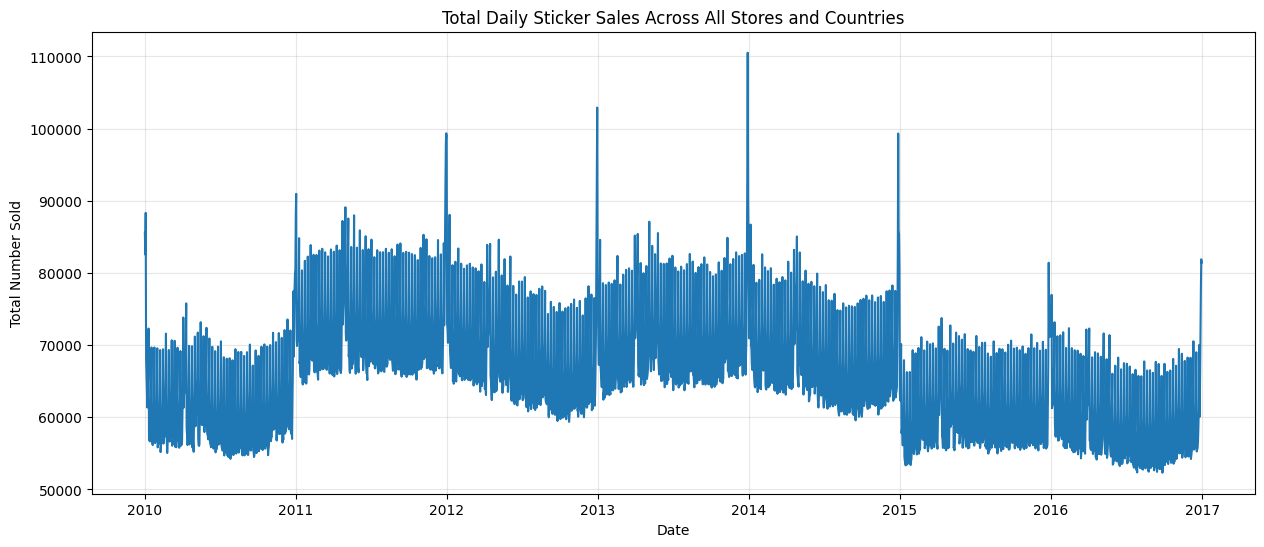

In [9]:
def load_and_inspect_data(train_path='train.csv', test_path='test.csv'):
    try:
        train_df = pd.read_csv(train_path)
        test_df = pd.read_csv(test_path)
    except FileNotFoundError:
        print("Error: Dataset files not found. Please ensure train.csv and test.csv are in the correct directory.")
        return None, None

    train_df['date'] = pd.to_datetime(train_df['date'])
    test_df['date'] = pd.to_datetime(test_df['date'])

    print("--- Training Data Overview ---")
    print(train_df.info())
    print("\n--- Missing Values in Training Data ---")
    print(train_df.isnull().sum())
    
    print("\n--- Unique Categories ---")
    print(f"Countries: {train_df['country'].unique()}")
    print(f"Stores: {train_df['store'].unique()}")
    print(f"Products: {train_df['product'].unique()}")
    
    print("\n--- Summary Statistics ---")
    print(train_df.describe(include='all'))

    return train_df, test_df

train_data, test_data = load_and_inspect_data()

if train_data is not None:
    plt.figure(figsize=(15, 6))
    daily_sales = train_data.groupby('date')['num_sold'].sum().reset_index()
    sns.lineplot(data=daily_sales, x='date', y='num_sold')
    plt.title('Total Daily Sticker Sales Across All Stores and Countries')
    plt.xlabel('Date')
    plt.ylabel('Total Number Sold')
    plt.grid(True, alpha=0.3)
    plt.show()

Feature Engineering

In [10]:
def engineer_features(df):
    df = df.copy()
    
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7.0)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7.0)
    
    df = pd.get_dummies(df, columns=['country', 'store', 'product'], drop_first=False)
    
    for col in df.select_dtypes(include=['bool']).columns:
        df[col] = df[col].astype(int)
        
    return df

def preprocess_data(train_df, test_df):
    print("Starting feature engineering...")
    
    train_processed = engineer_features(train_df)
    test_processed = engineer_features(test_df)
    
    train_processed, test_processed = train_processed.align(test_processed, join='left', axis=1, fill_value=0)
    
    if 'num_sold' in test_processed.columns:
        test_processed = test_processed.drop('num_sold', axis=1)
        
    print("Feature engineering complete.")
    print(f"New training shape: {train_processed.shape}")
    print(f"New test shape: {test_processed.shape}")
    
    return train_processed, test_processed

try:
    train_processed, test_processed = preprocess_data(train_data, test_data)
    print("\n--- Processed Training Data Sample ---")
    print(train_processed.head())
except NameError:
    print("Error: train_data or test_data not defined. Please run Step 1 data loading first.")

Starting feature engineering...
Feature engineering complete.
New training shape: (230130, 26)
New test shape: (98550, 25)

--- Processed Training Data Sample ---
   id       date  num_sold  year  month  day  dayofweek  is_weekend  \
0   0 2010-01-01       NaN  2010      1    1          4           0   
1   1 2010-01-01     973.0  2010      1    1          4           0   
2   2 2010-01-01     906.0  2010      1    1          4           0   
3   3 2010-01-01     423.0  2010      1    1          4           0   
4   4 2010-01-01     491.0  2010      1    1          4           0   

   month_sin  month_cos  ...  country_Norway  country_Singapore  \
0        0.5   0.866025  ...               0                  0   
1        0.5   0.866025  ...               0                  0   
2        0.5   0.866025  ...               0                  0   
3        0.5   0.866025  ...               0                  0   
4        0.5   0.866025  ...               0                  0   

   stor

Model Training and Evaluation

Preparing data for modeling...
Building and training Deep Learning model...
Epoch 1/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 175648.7812 - mae: 222.7323 - val_loss: 36039.7070 - val_mae: 119.2402
Epoch 2/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 26720.2695 - mae: 99.1466 - val_loss: 30709.1191 - val_mae: 100.6658
Epoch 3/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 23772.5703 - mae: 92.2360 - val_loss: 31902.3516 - val_mae: 101.1210
Epoch 4/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 22975.7188 - mae: 90.1122 - val_loss: 30092.4297 - val_mae: 96.2775
Epoch 5/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 22176.1543 - mae: 88.6592 - val_loss: 27571.9375 - val_mae: 94.7453
Epoch 6/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 21898.3477 - mae: 87.7220 - val_loss: 27818.4336 - val_mae: 92.3627
Epoch 7/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 21732.9668 - mae: 87.4799 - val_loss: 29637.0957 - val_mae: 97.4081
Epoch 8/30
692/692 ━━━━

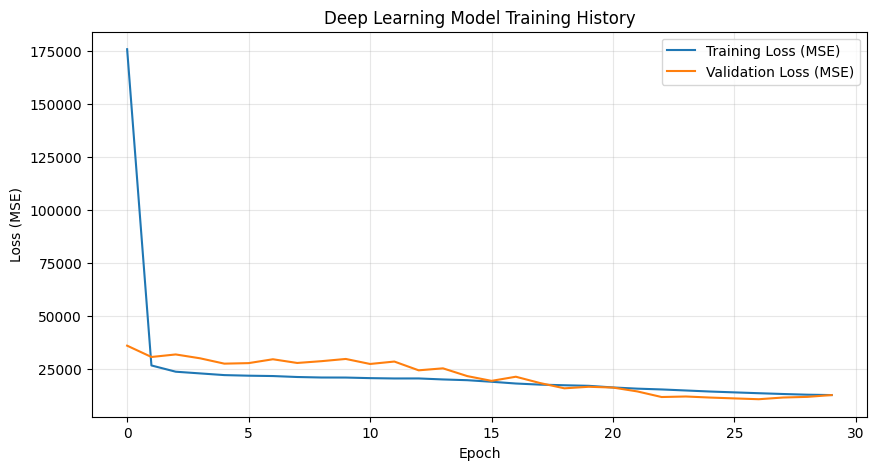

In [11]:
def prepare_and_train_model(train_df, test_df):
    print("Preparing data for modeling...")
    
    train_clean = train_df.dropna(subset=['num_sold']).copy()
    
    X = train_clean.drop(['id', 'date', 'num_sold'], axis=1)
    y = train_clean['num_sold']
    
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    X_test = test_df.drop(['id', 'date', 'num_sold'], axis=1, errors='ignore')
    X_test_scaled = scaler.transform(X_test)
    
    print("Building and training Deep Learning model...")
    tf.random.set_seed(42)
    
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=30,
        batch_size=256,
        verbose=1
    )
    
    print("\nEvaluating model on validation set...")
    val_predictions = model.predict(X_val_scaled)
    mae = mean_absolute_error(y_val, val_predictions)
    rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    
    print(f"Validation Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Validation Root Mean Squared Error (RMSE): {rmse:.2f}")
    
    return model, history, scaler, X_test_scaled

try:
    dl_model, training_history, feature_scaler, X_test_ready = prepare_and_train_model(train_processed, test_processed)
    
    plt.figure(figsize=(10, 5))
    plt.plot(training_history.history['loss'], label='Training Loss (MSE)')
    plt.plot(training_history.history['val_loss'], label='Validation Loss (MSE)')
    plt.title('Deep Learning Model Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
except NameError:
    print("Error: train_processed or test_processed not defined. Please run Step 2 feature engineering first.")